# Car price prediction

Linear regression trained with gradient descent from scratch, using log prices and ridge penalty 10.

## 1. Data cleaning
Manufacturer spelling is corrected. The row ID and full car name are excluded.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd

CATEGORIES = ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody',
              'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
              'fuelsystem', 'manufacturer']
BRANDS = {'alfa-romero': 'alfa-romeo', 'maxda': 'mazda', 'porcshce': 'porsche',
          'toyouta': 'toyota', 'vokswagen': 'volkswagen', 'vw': 'volkswagen'}


def clean_features(data):
    features = data.drop(columns=['car_ID', 'CarName', 'price'], errors='ignore').copy()
    names = data.CarName.astype('string').str.strip().str.lower()
    features['manufacturer'] = names.str.split().str[0].replace(BRANDS)
    for column in CATEGORIES:
        features[column] = features[column].astype('string').str.strip().str.lower()
    return features


data = pd.read_csv('CarPrice_Assignment.csv')
features = clean_features(data)
prices = data.price.to_numpy(float)
assert np.isfinite(prices).all() and (prices > 0).all()
print(f'{len(data)} cars; {data.isna().sum().sum()} missing values')
display(data.head(3))


205 cars; 0 missing values


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0


## 2. Data preparation
The split contains 164 training cars and 41 test cars. Identical predictors stay together. Encoding, imputation and scaling are fitted on training rows only.

In [2]:
def holdout_split(groups, seed=42):
    selected, count = [], 0
    for group in np.random.default_rng(seed).permutation(np.unique(groups)):
        selected.append(group)
        count += np.sum(groups == group)
        if count >= np.ceil(0.2 * len(groups)):
            break
    is_test = np.isin(groups, selected)
    return np.flatnonzero(~is_test), np.flatnonzero(is_test)


def group_folds(groups, seed=42):
    unique, counts = np.unique(groups, return_counts=True)
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(unique))
    order = order[np.argsort(-counts[order], kind='stable')]
    sizes = np.zeros(5, dtype=int)
    folds = np.empty(len(groups), dtype=int)
    for i in order:
        fold = int(rng.choice(np.flatnonzero(sizes == sizes.min())))
        folds[groups == unique[i]] = fold
        sizes[fold] += counts[i]
    return folds


groups = pd.util.hash_pandas_object(features, index=False).to_numpy()
train, test = holdout_split(groups)
assert not set(groups[train]) & set(groups[test])
print(f'Training: {len(train)} cars | Testing: {len(test)} cars')


Training: 164 cars | Testing: 41 cars


In [3]:
def encode(features, settings):
    table = features.copy()
    for column, median in settings['medians'].items():
        table[column] = pd.to_numeric(table[column], errors='coerce').replace(
            [np.inf, -np.inf], np.nan).fillna(median)
    for column in CATEGORIES:
        values = table[column].fillna(settings['modes'][column])
        table[column] = pd.Categorical(values, categories=settings['levels'][column])
    table = pd.get_dummies(table, columns=CATEGORIES, drop_first=True,
                           prefix_sep='=', dtype=float)
    return np.ascontiguousarray(table.to_numpy(float)), list(table.columns)


def fit_preprocessor(features):
    numeric = [column for column in features if column not in CATEGORIES]
    settings = {'medians': {}, 'modes': {}, 'levels': {}}
    for column in numeric:
        values = pd.to_numeric(features[column], errors='coerce').replace([np.inf, -np.inf], np.nan)
        settings['medians'][column] = float(values.median()) if values.notna().any() else 0.0
    for column in CATEGORIES:
        values = features[column].dropna()
        mode = str(values.mode().iloc[0]) if len(values) else '__missing__'
        settings['modes'][column] = mode
        settings['levels'][column] = sorted(features[column].fillna(mode).unique())
    matrix, settings['feature_names'] = encode(features, settings)
    settings['means'] = matrix.mean(axis=0)
    settings['scales'] = matrix.std(axis=0)
    settings['scales'][settings['scales'] < 1e-12] = 1.0
    return settings


def transform(features, settings):
    matrix, names = encode(features, settings)
    assert names == settings['feature_names']
    return (matrix - settings['means']) / settings['scales']



## 3. Gradient descent
The gradient combines squared prediction error with a ridge penalty. Momentum accelerates the updates, and the intercept is unpenalized. A training-residual correction converts log predictions back to prices.

In [4]:
def gradient_descent(design, target, alpha=10, max_iter=25000, tolerance=1e-7,
                     accelerated=True):
    n = len(target)
    target_mean, target_scale = np.mean(target), np.std(target)
    target_scale = max(float(target_scale), 1e-12)
    z = (target - target_mean) / target_scale
    gram, rhs = design.T @ design / n, design.T @ z / n
    penalty = np.full(design.shape[1], alpha / n)
    penalty[0] = 0
    rate = 1 / (max(float(np.linalg.eigvalsh(gram)[-1]), 1e-12) + alpha / n)
    weights = np.zeros(design.shape[1])
    lookahead, momentum_time = weights.copy(), 1.0

    def objective(w):
        return float(0.5*np.mean(z*z) - np.sum(rhs*w)
                     + 0.5*np.sum(w*(gram@w + penalty*w)))

    loss = objective(weights)
    history = [{'iteration': 0, 'objective': loss}]
    for iteration in range(1, max_iter + 1):
        gradient = gram @ lookahead - rhs + penalty * lookahead
        updated = lookahead - rate * gradient
        if objective(updated) > loss + 1e-12:
            updated = weights - rate * (gram @ weights - rhs + penalty * weights)
            momentum_time = 1.0
        next_time = (1 + np.sqrt(1 + 4*momentum_time**2)) / 2
        momentum = (momentum_time - 1) / next_time if accelerated else 0
        lookahead = updated + momentum * (updated - weights)
        weights, momentum_time = updated, next_time
        loss = objective(weights)
        if iteration % 25 == 0 or iteration == max_iter:
            history.append({'iteration': iteration, 'objective': loss})
            norm = float(np.max(np.abs(gram @ weights - rhs + penalty * weights)))
            if norm <= tolerance:
                break
    if norm > tolerance:
        raise RuntimeError('Gradient descent did not converge')
    weights *= target_scale
    weights[0] += target_mean
    return {'weights': weights, 'iterations': iteration, 'gradient_norm': norm,
            'learning_rate': rate, 'history': history}


def fit_model(matrix, prices):
    design = np.column_stack([np.ones(len(matrix)), matrix])
    log_prices = np.log(prices)
    model = gradient_descent(design, log_prices)
    model['smearing'] = float(np.exp(log_prices - design @ model['weights']).mean())
    return model


def predict_model(model, matrix):
    design = np.column_stack([np.ones(len(matrix)), matrix])
    return np.exp(design @ model['weights']) * model['smearing']



## 4. Cross-validation
Five grouped folds are repeated three times. Preprocessing and model fitting are repeated within each training fold.

In [5]:
def metrics(actual, predicted):
    actual, predicted = np.asarray(actual, float), np.asarray(predicted, float)
    error = actual - predicted
    absolute = np.abs(error)
    variance = np.sum((actual - actual.mean())**2)
    nonzero = np.abs(actual) > 1e-12
    total = np.abs(actual) + np.abs(predicted)
    return {'MAE': float(absolute.mean()), 'MSE': float(np.mean(error**2)),
            'RMSE': float(np.sqrt(np.mean(error**2))),
            'R2': float(1 - np.sum(error**2)/variance) if variance > 0 else None,
            'MAPE_pct': float(100*np.mean(absolute[nonzero]/np.abs(actual[nonzero]))) if nonzero.any() else None,
            'sMAPE_pct': float(200*np.mean(np.divide(absolute, total, out=np.zeros_like(absolute), where=total > 1e-12))),
            'MedianAE': float(np.median(absolute))}


In [6]:
cv_rows, cv_predictions, cv_optimization = [], [], []
splits = pd.DataFrame({'car_ID': data.car_ID, 'predictor_group': [f'{int(g):016x}' for g in groups],
                       'split': np.where(np.isin(np.arange(len(data)), test), 'test', 'train')})
for repeat in range(3):
    folds = group_folds(groups[train], seed=42 + repeat)
    splits[f'cv_repeat_{repeat+1}_fold'] = -1
    splits.loc[train, f'cv_repeat_{repeat+1}_fold'] = folds
    for fold in range(5):
        fit_rows, valid_rows = train[folds != fold], train[folds == fold]
        assert not set(groups[fit_rows]) & set(groups[valid_rows])
        settings = fit_preprocessor(features.iloc[fit_rows])
        model = fit_model(transform(features.iloc[fit_rows], settings), prices[fit_rows])
        prediction = predict_model(model, transform(features.iloc[valid_rows], settings))
        cv_rows.append({'repeat': repeat+1, 'fold': fold, **metrics(prices[valid_rows], prediction)})
        cv_optimization.append({'repeat': repeat+1, 'fold': fold, 'iterations': model['iterations'],
                                'gradient_norm': model['gradient_norm']})
        cv_predictions.extend({'repeat': repeat+1, 'fold': fold, 'car_ID': int(data.iloc[i].car_ID),
                               'actual': float(prices[i]), 'predicted': float(p)}
                              for i, p in zip(valid_rows, prediction))
cv_predictions = pd.DataFrame(cv_predictions)
cv_metrics = metrics(cv_predictions.actual, cv_predictions.predicted)
print(f"Cross-validation RMSE: {cv_metrics['RMSE']:,.2f}")


Cross-validation RMSE: 2,372.69


## 5. Evaluation
MAE, RMSE and median absolute error use price units. MSE uses squared price units; MAPE and sMAPE use percentages.

In [7]:
settings = fit_preprocessor(features.iloc[train])
model = fit_model(transform(features.iloc[train], settings), prices[train])
train_prediction = predict_model(model, transform(features.iloc[train], settings))
test_prediction = predict_model(model, transform(features.iloc[test], settings))
evaluation = []
for split_name, rows, prediction in [('Train', train, train_prediction), ('Test', test, test_prediction)]:
    evaluation.append({'Model': 'Gradient descent', 'Split': split_name, **metrics(prices[rows], prediction)})
    for label, value in [('Mean baseline', prices[train].mean()), ('Median baseline', np.median(prices[train]))]:
        evaluation.append({'Model': label, 'Split': split_name, **metrics(prices[rows], np.full(len(rows), value))})
evaluation = pd.DataFrame(evaluation)
display(evaluation.round(4))
print(f"Converged in {model['iterations']} updates; gradient norm {model['gradient_norm']:.2e}")


,Model,Split,MAE,MSE,RMSE,R2,MAPE_pct,sMAPE_pct,MedianAE
0,Gradient descent,Train,981.9863,2.133309e+06,1460.5852,0.9662,7.7658,7.6648,715.4544
1,Mean baseline,Train,5766.8201,6.315640e+07,7947.1003,0.0000,49.7578,41.7643,4753.6626
2,Median baseline,Train,5386.8821,7.088849e+07,8419.5301,-0.1224,36.6654,38.5382,3342.5000
3,Gradient descent,Test,1391.3090,3.706014e+06,1925.1011,0.9429,10.8357,10.6087,1102.7990
4,Mean baseline,Test,6391.5680,6.492996e+07,8057.9130,-0.0003,55.3878,46.6769,5275.6626
5,Median baseline,Test,5924.3659,7.338635e+07,8566.5835,-0.1305,40.3982,42.6585,3821.0000


Converged in 225 updates; gradient norm 6.22e-08


## 6. Prediction errors
Residuals are actual minus predicted price. Positive residuals indicate underprediction.

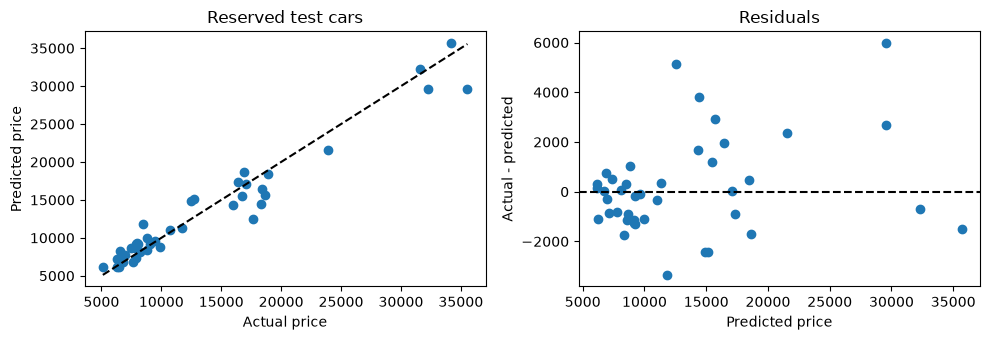

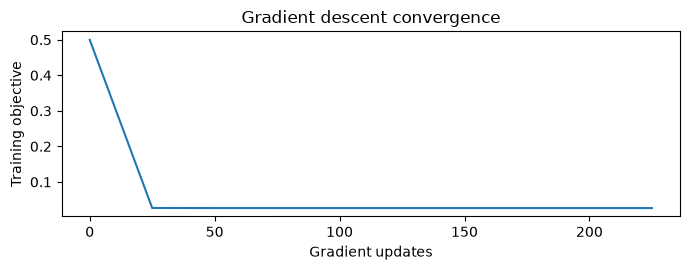

,car_ID,CarName,actual,predicted,residual,absolute_error
48,49,jaguar xf,35550.0,29565.41,5984.59,5984.59
172,173,toyota cressida,17669.0,12532.52,5136.48,5136.48
65,66,mazda glc,18280.0,14454.08,3825.92,3825.92
167,168,toyota corona liftback,8449.0,11796.72,-3347.72,3347.72
137,138,saab 99e,18620.0,15707.19,2912.81,2912.81


In [8]:
output = Path('results')
figures = output / 'figures'
figures.mkdir(parents=True, exist_ok=True)
errors = data.iloc[test][['car_ID', 'CarName', 'price']].rename(columns={'price': 'actual'}).copy()
errors['predicted'] = test_prediction
errors['residual'] = errors.actual - errors.predicted
errors['absolute_error'] = errors.residual.abs()
history = pd.DataFrame(model['history'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(errors.actual, errors.predicted)
limits = [errors.actual.min(), errors.actual.max()]
axes[0].plot(limits, limits, 'k--')
axes[0].set(xlabel='Actual price', ylabel='Predicted price', title='Reserved test cars')
axes[1].scatter(errors.predicted, errors.residual)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set(xlabel='Predicted price', ylabel='Actual - predicted', title='Residuals')
fig.tight_layout()
fig.savefig(figures / 'test_diagnostics.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(history.iteration, history.objective)
ax.set(xlabel='Gradient updates', ylabel='Training objective', title='Gradient descent convergence')
fig.tight_layout()
fig.savefig(figures / 'training_loss.png', dpi=150)
plt.show()
display(errors.nlargest(5, 'absolute_error').round(2))


In [9]:
summary = {'alpha': 10, 'target': 'log', 'n_train': len(train), 'n_test': len(test),
           'iterations': model['iterations'], 'gradient_norm': model['gradient_norm'],
           'cv_metrics': cv_metrics, 'train_metrics': metrics(prices[train], train_prediction),
           'test_metrics': metrics(prices[test], test_prediction), 'smearing': model['smearing']}
for name, table in [('final_metrics', evaluation), ('test_predictions', errors),
                    ('cv_fold_metrics', pd.DataFrame(cv_rows)), ('cv_predictions', cv_predictions),
                    ('cv_convergence', pd.DataFrame(cv_optimization)), ('split_assignments', splits),
                    ('training_loss', history), ('cv_results', pd.DataFrame([cv_metrics]))]:
    table.to_csv(output / f'{name}.csv', index=False)
pd.DataFrame({'feature': ['intercept'] + settings['feature_names'],
              'coefficient': model['weights']}).to_csv(output / 'coefficients.csv', index=False)
(output / 'summary.json').write_text(json.dumps(summary, indent=2) + '\n')
saved_settings = {key: value.tolist() if isinstance(value, np.ndarray) else value for key, value in settings.items()}
(output / 'preprocessing.json').write_text(json.dumps(saved_settings, indent=2) + '\n')
np.savez(output / 'model_weights.npz', weights=model['weights'], smearing=model['smearing'], alpha=10, target='log')
assert np.isfinite(test_prediction).all()
print('Results saved in results/.')


Results saved in results/.


Test R² is 0.9429 and RMSE is 1,925.10 price units. These results describe the supplied historical dataset.